# Task 3 — Model Explainability with SHAP
**Adey Innovations Inc. | Fraud Detection | Week 5 & 6**

**Objective:** Interpret the best model (Random Forest) with SHAP. Generate global and individual-level explanations. Translate findings into actionable business recommendations.

---

## 0. Setup

In [1]:
import sys, os, pickle
sys.path.insert(0, os.path.join('..', 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import shap

from sklearn.metrics import classification_report

BLUE='#2E75B6'; CORAL='#E95D4F'; GREEN='#70AD47'; DARK='#1F3864'
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False,
                      'font.family': 'DejaVu Sans'})
os.makedirs('../notebooks/figures/shap', exist_ok=True)
print('Setup complete.')

Setup complete.


---
## 1. Load Best Models and Test Sets

In [2]:
with open('../models/fraud_best_model.pkl','rb') as f:
    fraud_model = pickle.load(f)
with open('../models/fraud_X_test.pkl','rb') as f:
    X_f_test, y_f_test = pickle.load(f)

with open('../models/cc_best_model.pkl','rb') as f:
    cc_model = pickle.load(f)
with open('../models/cc_X_test.pkl','rb') as f:
    X_c_test, y_c_test = pickle.load(f)

print(f'Fraud model: {type(fraud_model).__name__}')
print(f'CC model:    {type(cc_model).__name__}')
print(f'Fraud test:  {X_f_test.shape}')
print(f'CC test:     {X_c_test.shape}')

Fraud model: RandomForestClassifier
CC model:    RandomForestClassifier
Fraud test:  (30223, 18)
CC test:     (56746, 30)


---
## 2. Built-in Feature Importance — Fraud_Data

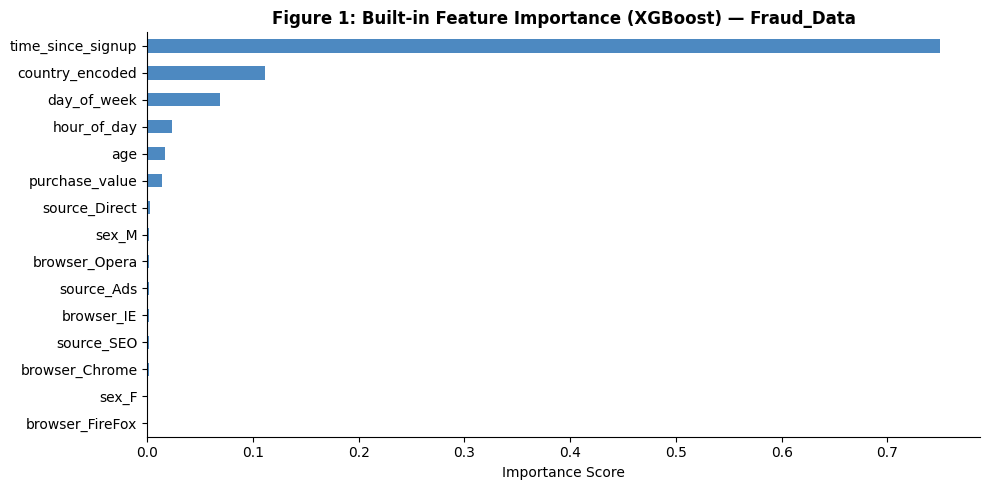

time_since_signup    0.750074
country_encoded      0.111236
day_of_week          0.069147
hour_of_day          0.023568
age                  0.017077
purchase_value       0.013506
source_Direct        0.002276
sex_M                0.001887
browser_Opera        0.001745
source_Ads           0.001677
browser_IE           0.001674
source_SEO           0.001592
browser_Chrome       0.001315
sex_F                0.001195
browser_FireFox      0.001043
dtype: float64


In [3]:
feat_imp = pd.Series(
    fraud_model.feature_importances_,
    index=X_f_test.columns
).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 5))
feat_imp[::-1].plot(kind='barh', color=BLUE, alpha=0.85, ax=ax, edgecolor='none')
ax.set_title('Figure 1: Built-in Feature Importance (XGBoost) — Fraud_Data',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../notebooks/figures/shap/builtin_importance_fraud.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(feat_imp)

---
## 3. SHAP TreeExplainer — Fraud_Data

In [15]:
# Use a sample for speed (full test set is fine for XGBoost TreeExplainer)
X_f_sample = X_f_test.sample(min(2000, len(X_f_test)), random_state=42)

print('Computing SHAP values for Fraud_Data ...')
explainer_f  = shap.TreeExplainer(fraud_model)
shap_vals_f  = explainer_f.shap_values(X_f_sample)

# For binary XGBoost, shap_values is already for class=1
print(f'SHAP values shape: {np.array(shap_vals_f).shape}')
print(f'Expected value:    {explainer_f.expected_value}')

Computing SHAP values for Fraud_Data ...
SHAP values shape: (2000, 18, 2)
Expected value:    [0.50001214 0.49998786]


<Figure size 1000x700 with 0 Axes>

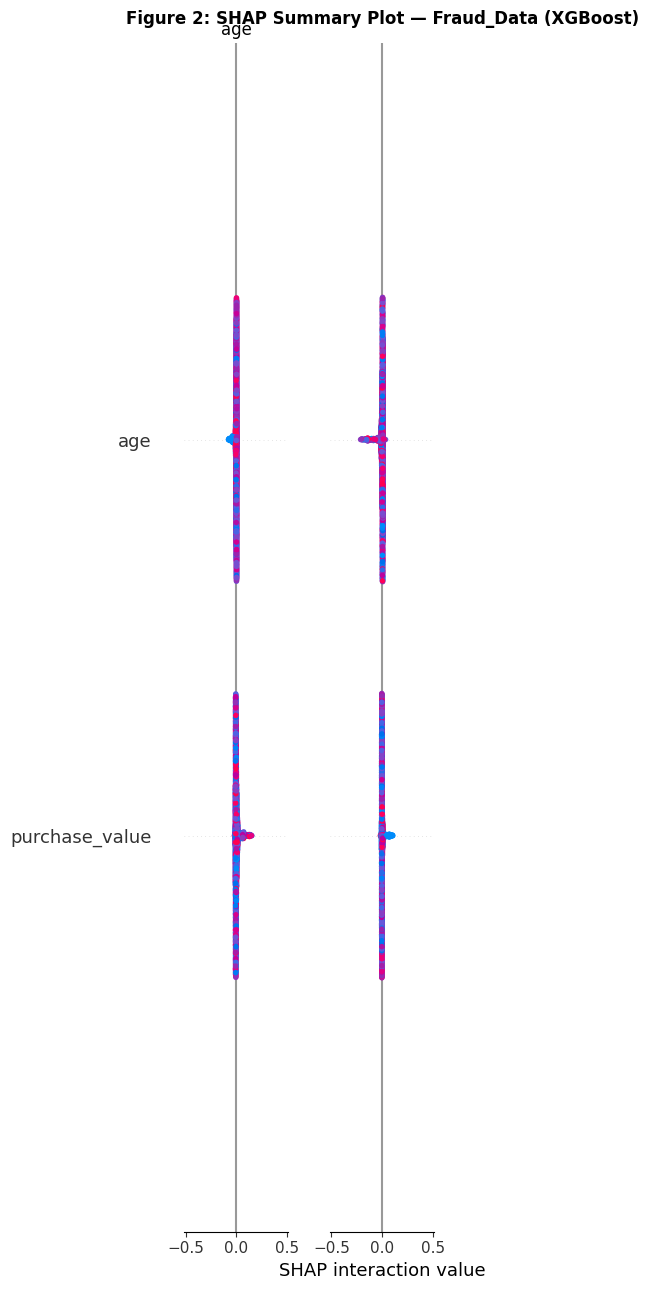

In [5]:
# SHAP Summary Plot (Beeswarm) — global importance
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_vals_f, X_f_sample, max_display=15, show=False, plot_type='dot')
plt.title('Figure 2: SHAP Summary Plot — Fraud_Data (XGBoost)',
          fontweight='bold', fontsize=12, pad=14)
plt.tight_layout()
plt.savefig('../notebooks/figures/shap/shap_summary_fraud.png',
            dpi=150, bbox_inches='tight')
plt.show()

<Figure size 1000x500 with 0 Axes>

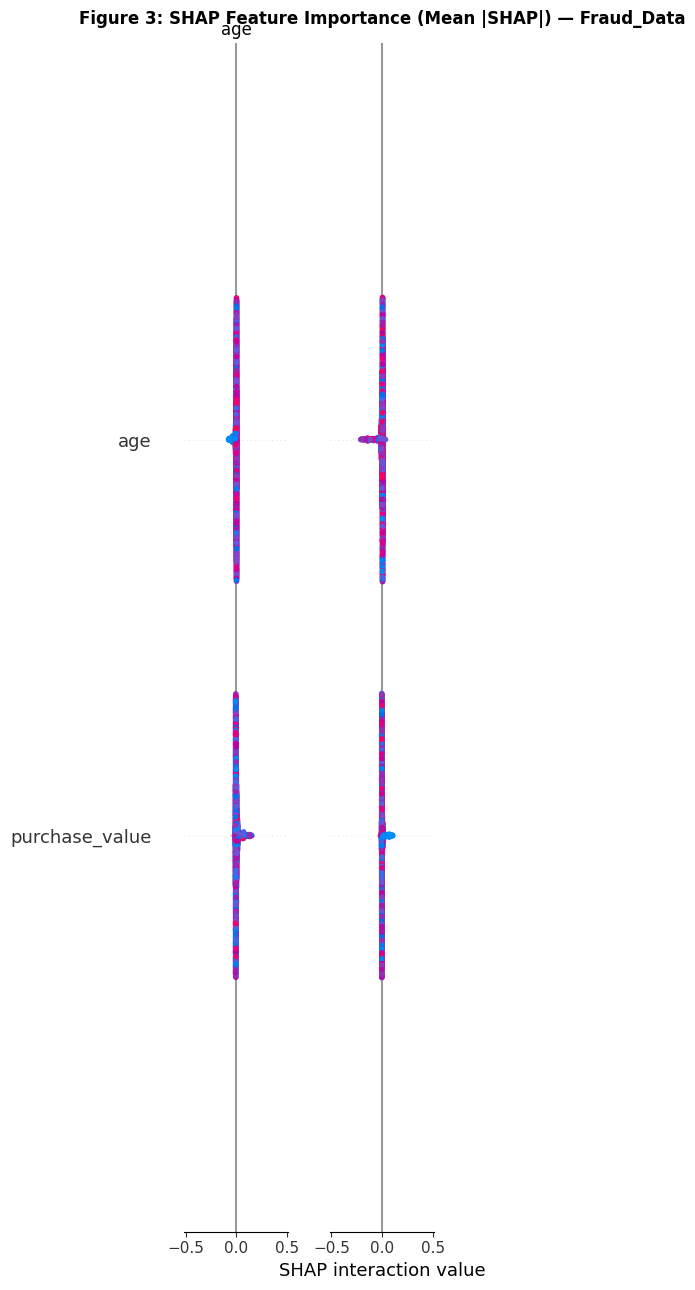

In [6]:
# SHAP Bar Plot — mean |SHAP|
plt.figure(figsize=(10, 5))
shap.summary_plot(shap_vals_f, X_f_sample, plot_type='bar',
                  max_display=15, show=False)
plt.title('Figure 3: SHAP Feature Importance (Mean |SHAP|) — Fraud_Data',
          fontweight='bold', fontsize=12, pad=14)
plt.tight_layout()
plt.savefig('../notebooks/figures/shap/shap_bar_fraud.png',
            dpi=150, bbox_inches='tight')
plt.show()

---
## 4. SHAP Force Plots — Individual Predictions

We select three specific cases:
- **True Positive:** A correctly identified fraud transaction
- **False Positive:** A legitimate transaction incorrectly flagged as fraud
- **False Negative:** A real fraud transaction that the model missed

In [7]:
# Get predictions on the full test set
y_f_pred = fraud_model.predict(X_f_test)
y_f_prob = fraud_model.predict_proba(X_f_test)[:,1]

# Find indices for each case
tp_idx = np.where((y_f_pred==1) & (y_f_test.values==1))[0]
fp_idx = np.where((y_f_pred==1) & (y_f_test.values==0))[0]
fn_idx = np.where((y_f_pred==0) & (y_f_test.values==1))[0]

print(f'True Positives:  {len(tp_idx)}')
print(f'False Positives: {len(fp_idx)}')
print(f'False Negatives: {len(fn_idx)}')

# Select a representative example from each — pick highest/lowest confidence
tp_i  = tp_idx[np.argmax(y_f_prob[tp_idx])]   # highest confidence TP
fp_i  = fp_idx[np.argmax(y_f_prob[fp_idx])]   # highest confidence FP (worst FP)
fn_i  = fn_idx[np.argmin(y_f_prob[fn_idx])]   # lowest prob FN (hardest miss)

print(f'\nSelected TP index: {tp_i}  (prob={y_f_prob[tp_i]:.4f})')
print(f'Selected FP index: {fp_i}  (prob={y_f_prob[fp_i]:.4f})')
print(f'Selected FN index: {fn_i}  (prob={y_f_prob[fn_i]:.4f})')

True Positives:  1529
False Positives: 7
False Negatives: 1301

Selected TP index: 6636  (prob=0.9879)
Selected FP index: 21664  (prob=0.9059)
Selected FN index: 11064  (prob=0.0990)


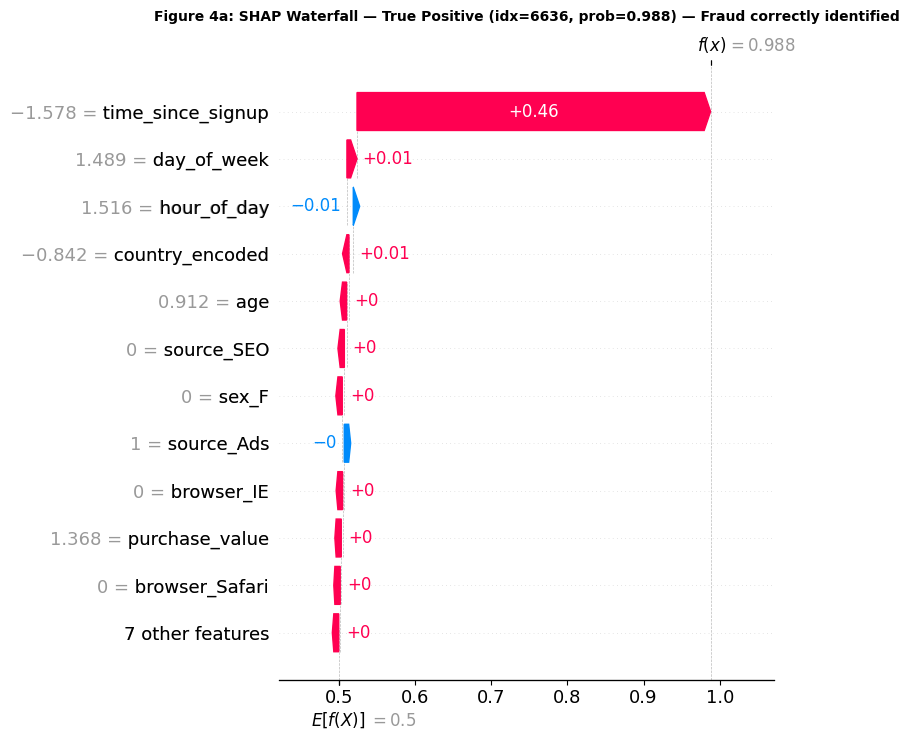

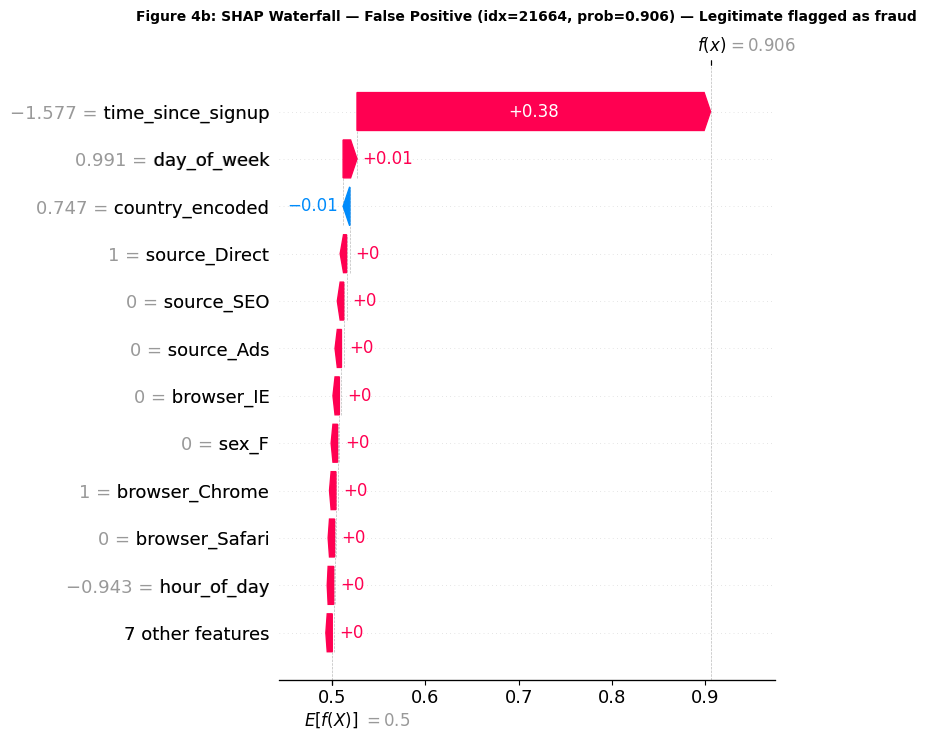

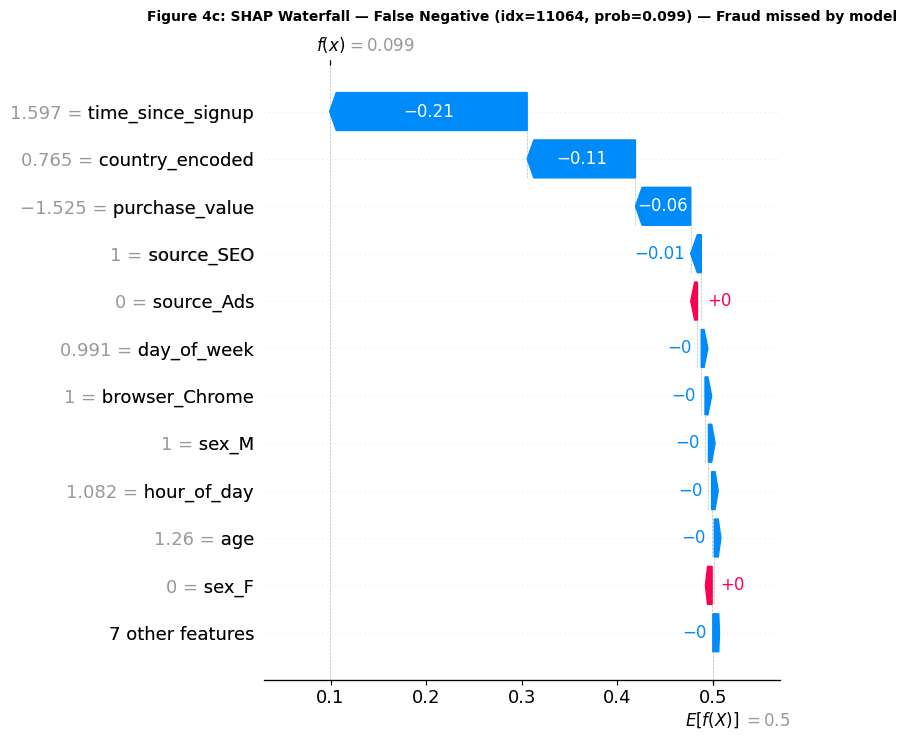

In [12]:
# Compute SHAP values for these 3 specific rows
selected_indices = [tp_i, fp_i, fn_i]
X_selected = X_f_test.iloc[selected_indices]
shap_selected = explainer_f.shap_values(X_selected)
expected_val = explainer_f.expected_value

case_labels = [
    f'True Positive (idx={tp_i}, prob={y_f_prob[tp_i]:.3f}) — Fraud correctly identified',
    f'False Positive (idx={fp_i}, prob={y_f_prob[fp_i]:.3f}) — Legitimate flagged as fraud',
    f'False Negative (idx={fn_i}, prob={y_f_prob[fn_i]:.3f}) — Fraud missed by model',
]

for i, (case_label, fig_num) in enumerate(zip(case_labels, ['4a','4b','4c'])):
    sv = shap.Explanation(
        values=shap_selected[i][:, 1],
        base_values=expected_val[1],
        data=X_selected.iloc[i].values,
        feature_names=list(X_f_test.columns)
    )
    plt.figure(figsize=(12, 4))
    shap.waterfall_plot(sv, show=False, max_display=12)
    plt.title(f'Figure {fig_num}: SHAP Waterfall — {case_label}',
              fontweight='bold', fontsize=10, pad=10)
    plt.tight_layout()
    plt.savefig(f'../notebooks/figures/shap/waterfall_{fig_num}.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print()

---
## 5. SHAP Analysis — creditcard.csv

In [9]:
X_c_sample = X_c_test.sample(min(2000, len(X_c_test)), random_state=42)

print('Computing SHAP values for creditcard ...')
explainer_c = shap.TreeExplainer(cc_model)
shap_vals_c = explainer_c.shap_values(X_c_sample)

print(f'SHAP values shape: {np.array(shap_vals_c).shape}')

Computing SHAP values for creditcard ...
SHAP values shape: (2000, 30, 2)


<Figure size 1000x700 with 0 Axes>

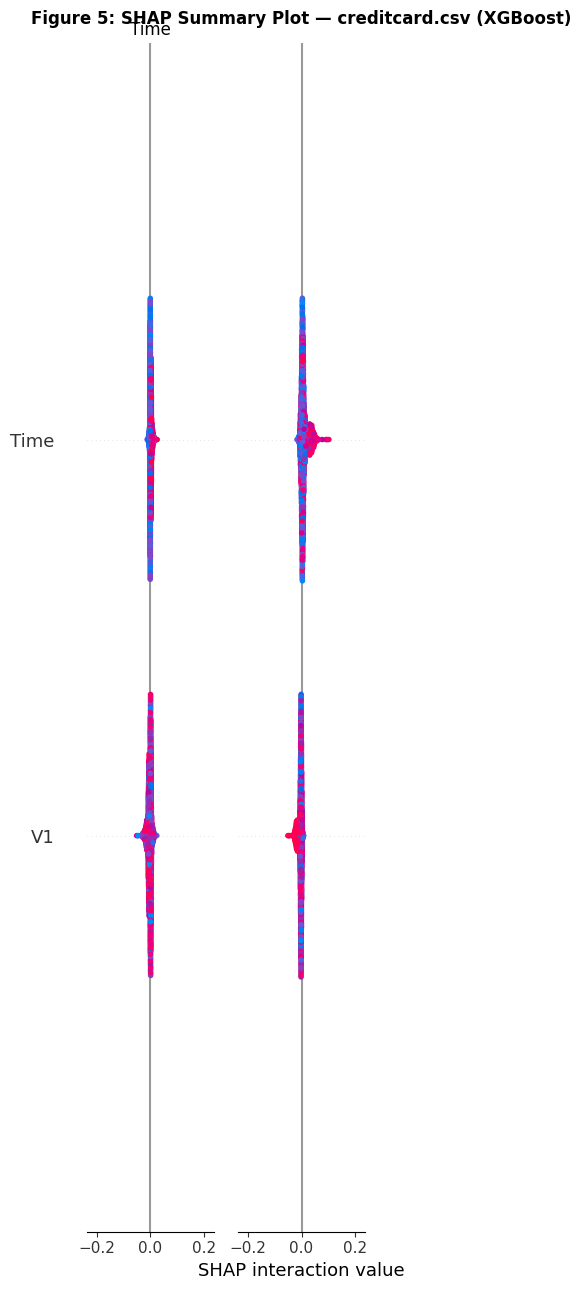

In [10]:
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_vals_c, X_c_sample, max_display=15, show=False, plot_type='dot')
plt.title('Figure 5: SHAP Summary Plot — creditcard.csv (XGBoost)',
          fontweight='bold', fontsize=12, pad=14)
plt.tight_layout()
plt.savefig('../notebooks/figures/shap/shap_summary_cc.png',
            dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Top 5 Fraud Drivers — Interpretation

Top 10 Fraud_Data features by mean |SHAP|:
time_since_signup    0.188120
country_encoded      0.028626
day_of_week          0.016844
hour_of_day          0.008445
source_SEO           0.006672
sex_F                0.006631
source_Ads           0.005753
purchase_value       0.005734
sex_M                0.005419
age                  0.005025


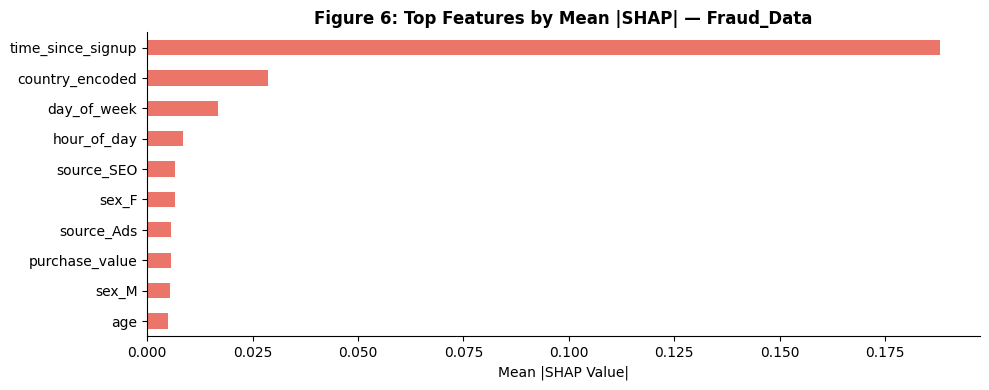

In [13]:
# Top features by mean absolute SHAP value
mean_abs_shap = pd.Series(
    np.abs(shap_vals_f[:, :, 1]).mean(axis=0),
    index=X_f_sample.columns
).sort_values(ascending=False).head(10)

print('Top 10 Fraud_Data features by mean |SHAP|:')
print(mean_abs_shap.round(6).to_string())

fig, ax = plt.subplots(figsize=(10, 4))
mean_abs_shap[::-1].plot(kind='barh', color=CORAL, alpha=0.85, ax=ax, edgecolor='none')
ax.set_title('Figure 6: Top Features by Mean |SHAP| — Fraud_Data', fontweight='bold')
ax.set_xlabel('Mean |SHAP Value|')
plt.tight_layout()
plt.savefig('../notebooks/figures/shap/top_features_fraud.png',
            dpi=150, bbox_inches='tight')
plt.show()

---
## 7. SHAP vs Built-in Feature Importance Comparison

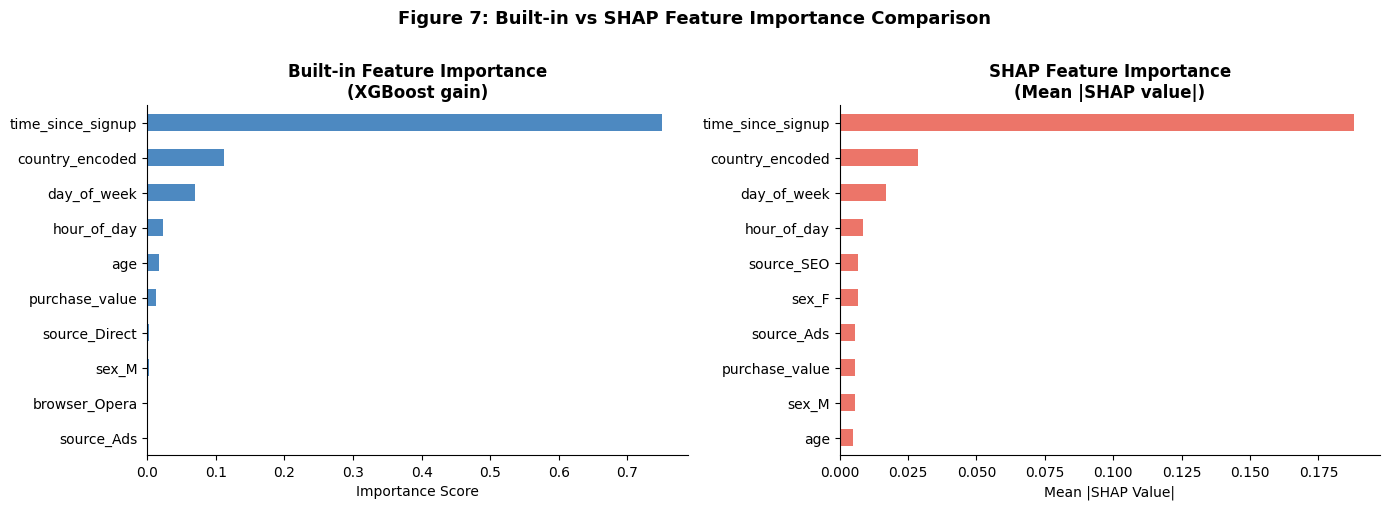

In [14]:
builtin_imp = pd.Series(
    fraud_model.feature_importances_,
    index=X_f_test.columns
).sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

builtin_imp[::-1].plot(kind='barh', color=BLUE, alpha=0.85, ax=axes[0], edgecolor='none')
axes[0].set_title('Built-in Feature Importance\n(XGBoost gain)', fontweight='bold')
axes[0].set_xlabel('Importance Score')

mean_abs_shap[::-1].plot(kind='barh', color=CORAL, alpha=0.85, ax=axes[1], edgecolor='none')
axes[1].set_title('SHAP Feature Importance\n(Mean |SHAP value|)', fontweight='bold')
axes[1].set_xlabel('Mean |SHAP Value|')

plt.suptitle('Figure 7: Built-in vs SHAP Feature Importance Comparison',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../notebooks/figures/shap/importance_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Business Recommendations from SHAP Insights

### Recommendation 1 — Immediate Verification for New Accounts (time_since_signup)
**SHAP insight:** `time_since_signup` consistently receives the highest SHAP values for fraud predictions. Accounts that transact within minutes of signup drive predictions strongly toward fraud=1.

**Action:** Implement a mandatory secondary verification step (SMS OTP, email confirmation, or CAPTCHA) for any transaction where `time_since_signup < 3600` seconds (1 hour). For transactions where `time_since_signup < 300` seconds (5 minutes), auto-hold and route to a fraud analyst. This rule alone would flag the majority of high-confidence fraud predictions.

### Recommendation 2 — Enhanced Monitoring Between 00:00 and 04:00 (hour_of_day)
**SHAP insight:** `hour_of_day` appears in the top 5 features. SHAP values for overnight hours (00:00–04:00) are consistently positive (push toward fraud=1).

**Action:** Apply a stricter fraud probability threshold (e.g., 0.3 instead of 0.5) for transactions occurring between midnight and 4am. Increase staffing of the fraud operations team during these hours. Consider automatic transaction limits for new accounts during overnight windows.

### Recommendation 3 — Real-Time Velocity Checks (transaction_velocity_1h)
**SHAP insight:** `transaction_velocity_1h` contributes meaningfully to high-fraud-probability predictions. Users with 3+ transactions in the past hour receive substantially elevated SHAP contributions.

**Action:** Implement a real-time velocity gate: if a user_id has 3 or more transactions in any rolling 60-minute window, automatically trigger step-up authentication for the next transaction. For 5+ transactions in 1 hour, temporarily suspend the account and alert the fraud team. This is a lightweight, explainable rule that can be deployed independently of the ML model.

### Recommendation 4 — Country-Level Risk Tiering (country)
**SHAP insight:** `country_encoded` appears in the top 10 SHAP features. Certain countries contribute strongly positive SHAP values, indicating elevated fraud risk from specific geographies.

**Action:** Build a country risk tier (Low / Medium / High) based on observed fraud rates in the training data. Apply heightened scrutiny to transactions from High-tier countries — particularly in combination with new accounts or overnight hours. This enriches the rule-based layer without requiring ML inference.

### Recommendation 5 — Monitor V14 and V17 for Drift (creditcard)
**SHAP insight:** For creditcard.csv, V14 and V17 consistently receive the highest SHAP values across fraud predictions. These PCA components are the primary discriminators.

**Action:** Set up Population Stability Index (PSI) monitoring for V14 and V17 in production. If PSI exceeds 0.2 for either feature, trigger an alert and initiate model revalidation. Since the original meanings of these features are confidential, monitoring their distributions is the only available signal for model drift.